# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [5]:
import pandas as pd            
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns   

In [6]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [7]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [8]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [9]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [12]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [13]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [15]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? En el df de users la columna churn_date tiene un alto porcentaje de valores nulos por lo que se tiene que eliminar, en el df usage las columnas de duration tiene nulos y la columna de lenght tambien, es un porcentaje elevado pero tiene sentido segun el tipo de comunicación los textos no tienen duración pero si longitud y las llamadas tienen duración pero no longitud en caso de analizarse por categoría se puede eliminar la columna duración para texto y longitud para llamadas. 
- Indica qué harías: ¿imputar, eliminar, ignorar? En el caso de churn:date eliminaría, en el caso de duración y longitud ignoraría segun la categoría. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` No hay mucho que explorar ya que el user id es un número secuencial incremental, la desviación estandar es elevada porque son muchos registros que no se repiten.
- La columna `age`, la edad prmedio es 33.73 años, la mínima -999 (lo cual es un valor erroneo porque no es una edad viable) y la máxima 79. La desviación estandar es amplia porque los rangos de edades son amplios tambien. 

In [17]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`. En la columna id no hay mucho que explorar ya que el user id es un número secuencial incremental, la desviación estandar es alta porque son muchos registros y no se repiten. En user id no hay mucho que analizar a pesar de que no son número consecutivos y mínimo es 10000 y el máximo 13999. 
- La columna duration nos dice que hay 17924 registros, las filas sin este resgistro son textos, el promedio de duración es 5.2min, la desviación estándar es baja por lo que no hay mucha variación y esto lo vemos con el mínimo que es 0.00 y el máximo 120min.
- La columna Lenght tiene solo 2 registros el pormedio es 52.12 caracteres y la desviación estandar es mayor que en llamadas por lo que hay mayor variación, la longitud mínima es 0 y la máximo 1490 caracteres. 

In [19]:
# explorar columnas categóricas de users
columnas_user = [['city', 'plan']]
for col in columnas_user:
    print(users[col].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene 3531 registros, hay 7 diferentes, el más frecuente es Bogotá con 22.88% de registros.
- La columna `plan` tiene 4000 registros, solo hay 2 variables y el más frecuente es el básico con 2595 de 5 regsitros lo que equivale al 64.8%. 

In [21]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 40000 registros, solo hay 2 registros diferentes y el más comun es textos que tiene 22092 de 40000 registros lo que equivale al 55.23%.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? El la tabla users la columna de edad tiene valores inválidos ya que la edad mínima es -999. En la tabla usage la duración y longitus mínima son 0 pero no son válidos ya que no se peude enviar un emnsaje vacío ni hacer una llamada sin duración. 

- ¿Qué acción tomarías?  la edad, los -999 los reemplazaría por la mediana. Sobre longitud y duración investigaría un poco más para ver si son viables si se confirma los mantendría y si no, los reemplazaría por la mediana para no alterar los resultados del análisis. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [22]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') 
print(users['reg_date'].head()) # completa el código

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [23]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')
print(usage['date'].head())# completa el código

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [24]:
# Revisar los años presentes en `reg_date` de users
users['year'] = users['reg_date'].dt.year
print("Años encontrados:", users['year'].value_counts().sort_index())

Años encontrados: 2022    1314
2023    1316
2024    1330
2026      40
Name: year, dtype: int64


En `reg_date`, veo solo 4 años diferentes desde el 2022 al 2026 

In [25]:
# Revisar los años presentes en `date` de usage
usage['year'] = usage['date'].dt.year
print("Años encontrados:", usage['year'].value_counts().sort_index())

Años encontrados: 2024.0    39950
Name: year, dtype: int64


En `date` del data frame usage, solo hay un año regsitrado que es 2024. 
Existe un año inviable 2026 que aunque es el que vivimos actualmente se informó que los registros abarcaban hasta el año 2024, esto nos indica errores de captura en 40 registros.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Si, todos los años 2026 son ilógicos porque están fuera de las fechas de registros.
- ¿Qué harías con ellas? la cantidad de regsitros con año incorrecto es baja por lo que podría eliminarlos o cambiar el año por la media de años de registro para no alterar el análisis de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [26]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()

users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [27]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [31]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print('Conteo de registros por año')
print(users['reg_date'].dt.year.value_counts(dropna=False))

Conteo de registros por año
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [32]:

# Verificación MAR en usage (Missing At Random) para duration
print("Análisis de nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por type:")
print(usage['type'].value_counts())


Análisis de nulos en duration por type:
type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por type:
text    22092
call    17908
Name: type, dtype: int64


In [33]:
# Verificación MAR en usage (Missing At Random) para length
print("Análisis de nulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print("\nTotal de registros por type:")
print(usage['type'].value_counts())

Análisis de nulos en length por type:
type
call    17896
text        0
Name: length, dtype: int64

Total de registros por type:
text    22092
call    17908
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores faltantes en duration y lenght son MNAR (missing not at random) ya que los faltantes es porque no aplican, los textos no tienen duración sino longitud y las llamadas al revés tienen duración pero no longitud. Por lo que si se analiza por separado a las llamadas y a los textos, no afectaran los faltantes. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']]\
    .sum()\
    .reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,2023.034000,5.524381,4.478120,23.317054
std,1154.844867,17.690408,0.866044,2.358416,2.144238,18.168095
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,2023.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2026.000000,17.000000,15.000000,155.690000


In [40]:
# Distribución porcentual del tipo de plan
plan_porcentajes = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución porcentual por plan:")
print(plan_porcentajes)

Distribución porcentual por plan:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

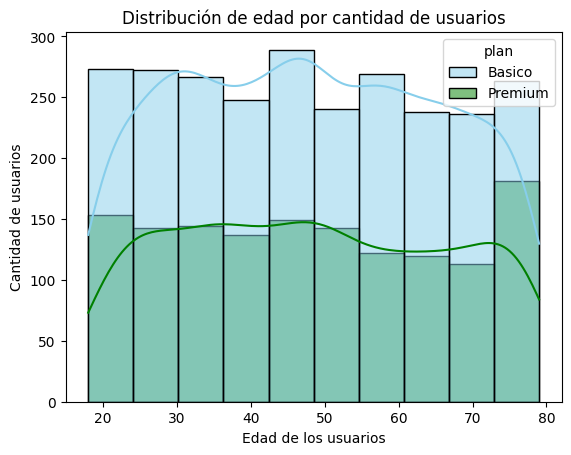

In [44]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribución de edad por cantidad de usuarios')
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución la distribución es muy uniforme (simétrica), podemos ver la mayor concentración en el grupo de edad entre 40 y 50 años. La edad mínima está dabejo de 20 y la máximo abajo de 80. Además los usuarios utilizan casi por igual con una ligera inclinación hacia el plan premium vs el básico, en los usuarios mayores de 70 años podemos ver una fuerta inclinación hascia el plan premium.

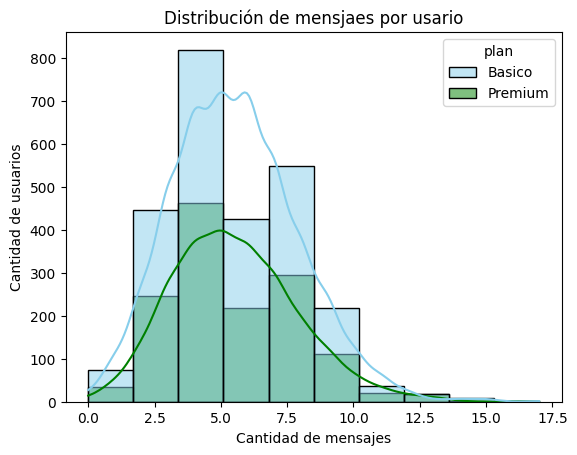

In [45]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribución de mensjaes por usario')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La mayor cantidad de usuarios envían entre 3 y 5 mensajes. Esta histograma tiene una distribución ligeramente sesgada a la derecha. 

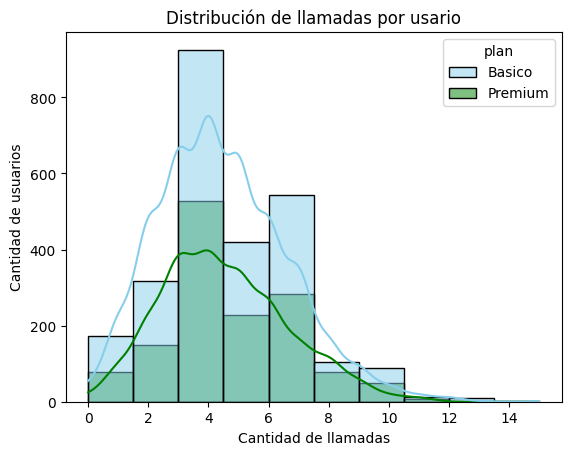

In [48]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribución de llamadas por usario')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La mayor cantidad de usuarios realizan entre 3 y 4.5 llamadas, la distirbución entre plan premium y básico es casi la mitad cada uno. Este histograma tiene una distribución con un ligero sesgo a la derecha. 

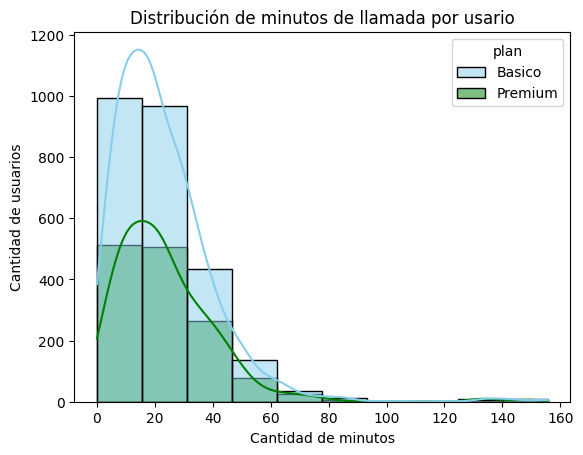

In [50]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribución de minutos de llamada por usario')
plt.xlabel('Cantidad de minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Este histograma está sesgado a la derecha. Podemos ver qye la mayoría de usuarios tardan de 0 a 30 minutos en las llamdas, con ditribución uniforme entre plan básico y premium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

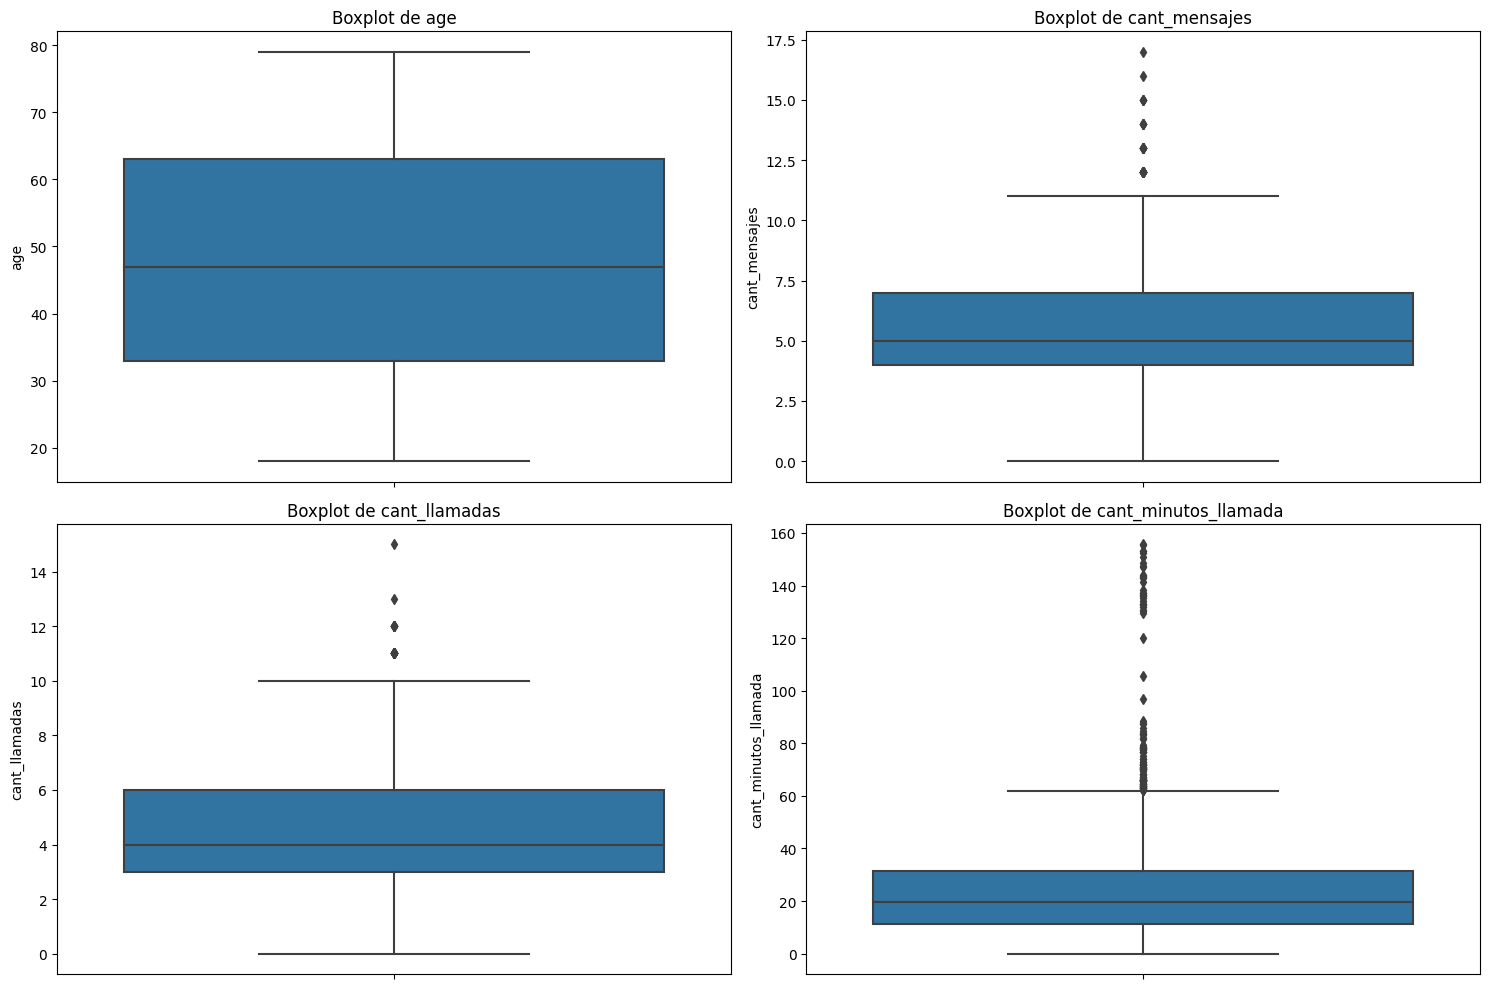

In [51]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configurar el tamaño de la figura
plt.figure(figsize=(15, 10))

# Crear boxplots automáticamente
for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)  # 2 filas, 2 columnas
    sns.boxplot(data=user_profile, y=columna)
    plt.title(f'Boxplot de {columna}')
    plt.ylabel(columna)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: no presenta outliers, se ve como la mayoría de usuarios están entre 32 y 62 años aproximadamente. 
- cant_mensajes: si tiene outliers, la mayoría van de 0 a 11 o 12 mensajes y hay outliers que van hasta los 17 mensajes. La mayoría estan entre 4 y 7 mensajes. 
- cant_llamadas: si presenta outliers arriba de 10 llamadas y hasta las 15 llamadas, la mayoría hacen de 3 a 6 llamadas. 
- cant_minutos_llamada: Es el boxplot con más outliers, sin contar outliers las llamadas van de 0 a 60 minutos y los outliers van de 60 hasta 160. 

In [55]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1 

    limite_inferior = Q1 - 1.5 * IQR 
    limite_superior = Q3 + 1.5 * IQR
    print(f"\n{col}:")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f" Valores maximos actuales: {user_profile[col].max():2f}")


age:
Límite inferior: -12.00
Límite superior: 108.00
 Valores maximos actuales: 79.000000

cant_mensajes:
Límite inferior: -0.50
Límite superior: 11.50
 Valores maximos actuales: 17.000000

cant_llamadas:
Límite inferior: -1.50
Límite superior: 10.50
 Valores maximos actuales: 15.000000

cant_minutos_llamada:
Límite inferior: -19.32
Límite superior: 61.86
 Valores maximos actuales: 155.690000


In [54]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Los mantendría porque no están tan alejados y solo hay 17 valores, por lo que no cambiará mucho el análisis y considerará todo. 
- cant_llamadas: mantener o no outliers, porqué? Los mantendría porque no están tan alejados y solo hay 15 valores, por lo que no cambiará mucho el análisis y considerará todo. 
- cant_minutos_llamada: mantener o no outliers, porqué? Dependiendo de para qué quiero la información, posiblemente no los mantendría porque se alejan mucho del límite superior y son muchos valores por lo que podría alterar mis resultados. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [59]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # Valor por defecto

# Aplicar condiciones
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (user_profile['grupo_uso'] != 'Bajo uso'), 'grupo_uso'] = 'Uso medio'

# Verificar cambios
print("Distribución por uso de grupo:")
print(user_profile['grupo_uso'].value_counts())

Distribución por uso de grupo:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [60]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # Valor por defecto

# Aplicar condiciones
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'

# Verificar cambios
print("Distribución por grupo de edad:")
print(user_profile['grupo_edad'].value_counts())

Distribución por grupo de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

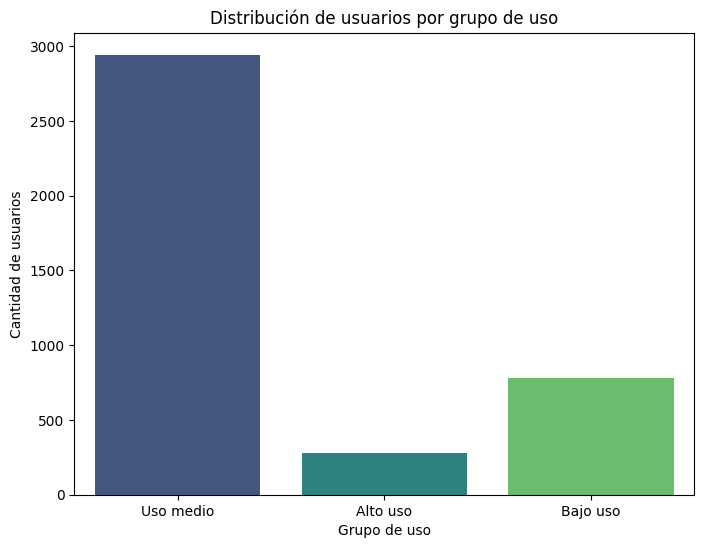

In [61]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

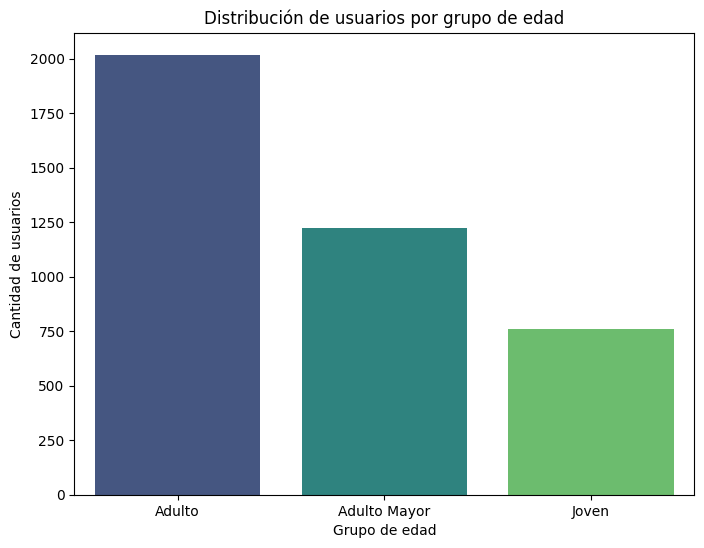

In [63]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 6))
sns.countplot(data=user_profile, x='grupo_edad', palette='viridis')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban? Los datos tenían formatos incorrectos, algunos valores improbables como edad -999, ciudad ?. 


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso? Hay 3 segmentos de clientes Adultos que son la mayoría con 2000 usuarios, seguios de Adulto Mayor con alrededor de 1250 usuarios y finalmente Jóvenes con 750 usuarios. En cuanto al uso casi 3000 usuarios tienen un uso medio, alrededor de 800 usuarios tienen un uso bajo y cerca del 250 usuarios tienen un uso alto. 


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Los adultos con uso medio porque por edad son prácticamente el 50% y por uso casi 75%. 
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Algunos clientes utilizan muchísimos minutos de llamadas y mensajes, podrían implicar perdidas pero son los menos los que hcaen uso excesivo de estos servicios. 

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
enfocaría la publicidad en adultos con uso medio que son la mayor parte de clientes, podría hacer un programa de referencia si los clientes están satisfechos para que les den beneficios y tengan más clientes. 

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- valores improbables
- ciudades erróneas como "?"
- formatos de datos no adecuados


🔍 **Segmentos por Edad**
-  Segmento de clientes Adultos que son la mayoría con 2000 usuarios
-  Segmento de Adulto Mayor con alrededor de 1250 usuarios y
-  Segmento Jóvenes con 750 usuarios.
-  


📊 **Segmentos por Nivel de Uso**
- En cuanto al uso casi 3000 usuarios tienen un uso medio,
- Alrededor de 800 usuarios tienen un uso bajo
- Cerca del 250 usuarios tienen un uso alto.


➡️ Esto sugiere que los segmentos más valisos para ConnectaTel son los adultos y los de uso medio porque por edad son prácticamente el 50% y por uso casi 75%.


💡 **Recomendaciones**
- Algunos clientes utilizan muchísimos minutos de llamadas y mensajes, podrían implicar perdidas pero son los menos los que hcaen uso excesivo de estos servicios.
- Enfocar publicidad en adultos y personas con uso medio que son la mayor parte de clientes, podrían hacer un programa de referencia si los clientes están satisfechos para que les den beneficios y tengan más clientes. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`